# 环境设置代码

我自己导入这么多库，，也是看到了不同的库有不同的作用，有数据处理的库，有神经网络专用的库，知道怎么用就可以。这块我基本上都理解了。


In [1]:
# ===================== 导入需要的库（带详细注释）=====================
import torch  # PyTorch 核心库：张量计算、自动求导、模型训练
import pandas as pd  # 数据处理库：读取表格、数据清洗
import numpy as np  # 数值计算库：数组、数学运算
import matplotlib.pyplot as plt  # 绘图库：画损失曲线、显示图片

# PyTorch 神经网络专用模块
import torch.nn as nn  # 构建网络层（线性层、卷积层等）
import torch.nn.functional as F  # 激活函数、池化等函数
import torch.optim as optim  # 优化器：SGD、Adam 等

# 数据集 + 数据加载器
from torchvision import datasets  # 内置经典数据集（MNIST、CIFAR10）
from torchvision import transforms  # 图像预处理：归一化、resize
from torch.utils.data import Dataset, DataLoader  # 自定义数据集 + 批量加载

# 工具库
import os  # 文件路径管理
import time  # 计时
import datetime  # 时间记录
from tqdm.auto import tqdm  # 训练进度条（非常好用）

# 忽略不影响运行的警告
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

c:\Users\Lenovo\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 读取数据

Train shape: (42000, 785)
Test shape: (28000, 784)


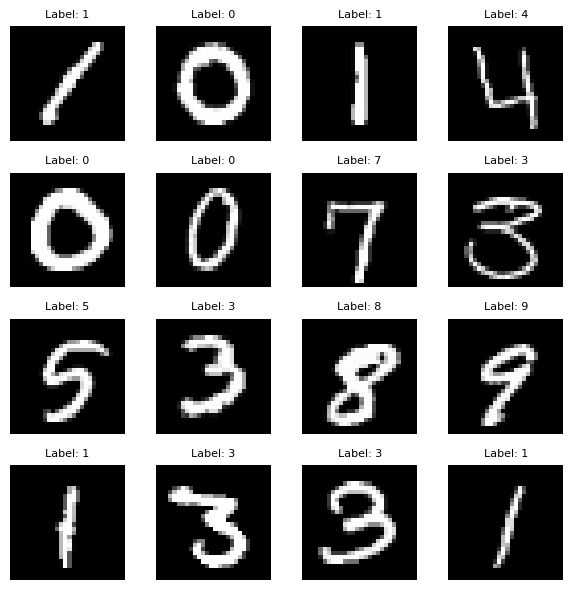

In [2]:
# ===================== 正确读取数据 + 可视化 =====================
# 正确路径（如果你已经Add data，就用这个）
input_dir = './data'
# 读取数据集
train_df = pd.read_csv(os.path.join(input_dir, 'train.csv'))
test_df = pd.read_csv(os.path.join(input_dir, 'test.csv'))

# 查看数据信息  ✅ 这里修好了
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# 显示 16 张数字图片
plt.figure(figsize=(6, 6))

for i in range(16):
    # 取第 i 个样本   ✅ 这里修好了
    sample = train_df.iloc[i]
    label = sample['label']
    pixels = sample.drop('label').values.reshape(28, 28)
    
    plt.subplot(4, 4, i + 1)
    plt.imshow(pixels, cmap='gray')
    plt.title(f"Label: {label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
# Check for the MNIST dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 读取设备

我第一次使用GPU，感觉还不错。感觉这种简单的数据，使用CPU或者GPU差不多，数据量比较少，用的时间差不多。不建议大家用GPU，感觉没必要



In [4]:
use_cuda = torch.cuda.is_available()

print(use_cuda)

# GPU specifications
if use_cuda:
    print(torch.cuda.device_count())
    print(torch.cuda.current_device())
    print(torch.cuda.device(torch.cuda.current_device()))
    print(torch.cuda.get_device_name(0))

num_gpus = torch.cuda.device_count() if use_cuda else 0
device = torch.accelerator.current_accelerator().type if use_cuda else 'cpu'
print(f'Using {device} device')

False
Using cpu device


In [5]:
# 检查 GPU 信息（跨平台兼容）
import subprocess
try:
    # 尝试获取 GPU 信息
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        print("="*80)
        print("GPU 设备信息")
        print("="*80)
        print(result.stdout)
    else:
        print("="*80)
        print("GPU 设备信息")
        print("="*80)
        print("未检测到 NVIDIA GPU 或 nvidia-smi 命令不可用")
        print(f"当前设备: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")
except FileNotFoundError:
    print("="*80)
    print("GPU 设备信息")
    print("="*80)
    print("nvidia-smi 命令不可用（可能未安装 NVIDIA 驱动）")
    print(f"当前设备: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")
except Exception as e:
    print(f"获取 GPU 信息时出错: {e}")

GPU 设备信息
nvidia-smi 命令不可用（可能未安装 NVIDIA 驱动）
当前设备: CPU


# 加载数据

学习到数据加载器，比如就像打饭阿姨，把数据喂给我的模型

In [6]:
# ---------------------- 路径配置 ----------------------
# 定义数据存放的文件夹路径（Kaggle 比赛标准路径）
input_dir = './data'

# 打印提示信息：当前目录文件列表
print("当前目录文件列表：")

# 列出指定文件夹下的所有文件和子文件夹，用于确认数据是否存在
print(os.listdir(input_dir))

# ---------------------- 自定义数据集类 ----------------------
# 继承 PyTorch 的 Dataset，创建自定义的手写数字数据集类
class DigitDataset(Dataset):
    
    # 初始化函数：创建数据集时自动调用
    # df：传入的 pandas 数据框（csv 读取后的数据）
    # transform：图像预处理方法
    # is_test：是否为测试集（测试集没有标签）
    def __init__(self, df, transform=None, is_test=False):
        # 把传入的数据保存到类内部变量
        self.df = df
        # 保存预处理方法
        self.transform = transform
        # 标记是否是测试集
        self.is_test = is_test
        
    # 返回数据集的总长度（多少张图片）
    def __len__(self):
        return len(self.df)
    
    # 根据索引 idx 获取一条数据（一张图片 + 标签）
    def __getitem__(self, idx):
        # 如果是测试集：没有标签，只取像素
        if self.is_test:
            # 取出第 idx 行所有数据 → 转为数组 →  reshape 成 28x28x1 的图片格式 → 转为浮点型
            image = self.df.iloc[idx].values.reshape(28, 28, 1).astype(np.float32)
        # 如果是训练/验证集：有标签，第一列是标签，后面是像素
        else:
            # 取出第 idx 行第 0 列：标签（数字 0-9）
            label = self.df.iloc[idx, 0]
            # 取出第 idx 行第 1 列到最后：像素数据 → reshape 成 28x28x1 → 转为浮点型
            image = self.df.iloc[idx, 1:].values.reshape(28, 28, 1).astype(np.float32)
        
        # 如果定义了预处理方法，就对图片进行处理
        if self.transform:
            image = self.transform(image)
        
        # 测试集只返回图片
        if self.is_test:
            return image
        # 训练/验证集返回 图片 + 标签
        return image, label

# ========== 关键修改：训练集、测试集使用不同预处理 ==========
# 训练集：数据增强 + 标准化，提高泛化
train_transform = transforms.Compose([
    transforms.ToTensor(),                   
    transforms.RandomRotation(20),          # 随机旋转 ±20度
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # 平移和缩放
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),  # 透视变换
    transforms.Normalize((0.1307,), (0.3081,))  
])

# 测试集/验证集：只归一化，不做任何随机变化
test_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize((0.1307,), (0.3081,))
])

# 划分训练、验证
train_data = train_df.sample(frac=0.8, random_state=42)
val_data = train_df.drop(train_data.index)

# 绑定不同预处理
train_dataset = DigitDataset(train_data, train_transform)
val_dataset = DigitDataset(val_data, test_transform)
test_dataset = DigitDataset(test_df, test_transform, is_test=True)

# 数据加载器
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)  # 训练打乱
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)   # 验证不打乱
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)  # 测试不打乱

print(f"训练集:{len(train_dataset)} 验证集:{len(val_dataset)}")

当前目录文件列表：
['sample_submission.csv', 'test.csv', 'train.csv']
训练集:33600 验证集:8400


# 简单CNN网络

In [7]:
# 定义一个CNN卷积神经网络类，继承自nn.Module（PyTorch所有模型都必须继承这个）
class CNN_Net(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        # 优化：更深的网络 + 残差连接
        
        # 第一层：卷积块
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        
        # 第二层：卷积块
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        
        # 第三层：卷积块
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x


# ==================== 模型、损失函数、优化器 ====================
# 创建模型实例，并把模型放到设备上（GPU/CPU）
model = CNN_Net().to(device)

# 定义损失函数：交叉熵损失，专门用于分类任务
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label Smoothing

# 定义优化器：Adam优化器，更新模型参数
# lr=1e-3：学习率，控制参数更新的步长
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 损失函数

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label Smoothing


# 优化器

In [9]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# 训练函数

In [10]:
# 设置训练的总轮数
n_epochs = 30  # 增加训练轮数

# 创建空列表，用于存储每一轮的训练损失和验证准确率
train_loss_curve = []
val_acc_curve = []

# 优化: 学习率调度器 - OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=1e-3,
    epochs=n_epochs,
    steps_per_epoch=len(train_loader)
)

# 定义模型训练函数
def model_train():
    # 将模型设置为训练模式
    model.train()

    # 记录训练开始的时间
    start = time.time()

    # 创建训练进度条
    pbar = tqdm(range(1, n_epochs + 1))

    # 外层循环：遍历每一个训练轮次
    for epoch in pbar:
        # 初始化当前轮次的总损失为0
        train_loss = 0.0

        # 内层循环：从数据加载器中批量读取图片和标签
        for images, labels in train_loader:
            # 将数据移动到指定设备
            images, labels = images.to(device), labels.to(device)
            
            # 清空梯度
            optimizer.zero_grad()
            
            # 前向传播
            outputs = model(images)
            
            # 计算损失
            loss = criterion(outputs, labels)
            
            # 反向传播
            loss.backward()
            
            # 更新参数
            optimizer.step()
            scheduler.step()
            
            # 累加损失
            train_loss += loss.item() * images.size(0)

        # 计算当前轮次的平均损失
        train_loss = train_loss / len(train_loader.dataset)
        train_loss_curve.append(train_loss)
        
        # ========== 验证集评估 ==========
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs = model(val_images)
                _, predicted = torch.max(outputs, 1)
                total += val_labels.size(0)
                correct += (predicted == val_labels).sum().item()
        val_acc = 100 * correct / total
        val_acc_curve.append(val_acc)
        model.train()
        
        # 更新进度条描述
        pbar.set_description(f'Epoch {epoch}  损失:{train_loss:.4f}  验证:{val_acc:.2f}%')

    # 记录训练结束的时间
    end = time.time()
    print(f"\n神经网络训练总耗时: {str(datetime.timedelta(seconds=round(end-start)))}")



In [11]:
model_train()

Epoch 30  损失:0.5444  验证:99.55%: 100%|██████████| 30/30 [1:37:35<00:00, 195.19s/it]


神经网络训练总耗时: 1:37:36


# 损失图

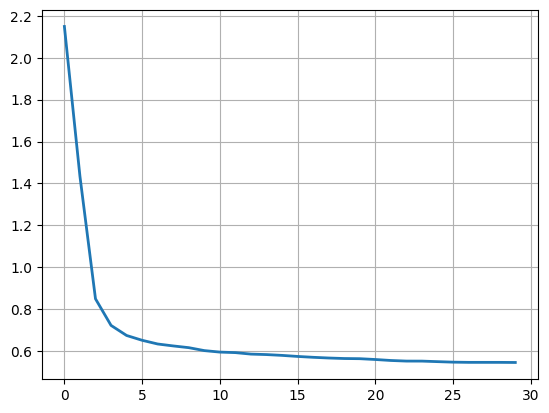

In [12]:
plt.plot(train_loss_curve, linewidth=2)
plt.grid(True)
plt.show()

# 测试准确性

In [13]:
# 定义模型评估函数（用于在验证集上测试模型准确率）
def model_eval():
    # 将模型设置为评估模式（关闭dropout、batchnorm等训练时才用的层）
    model.eval()
    
    # 初始化：预测正确的样本数量
    correct = 0
    
    # 初始化：验证集的总样本数量
    total = 0
    
    # 关闭梯度计算（评估时不需要更新参数，节省显存+加速）
    with torch.no_grad():
        # 遍历验证集的每一批数据（图片 + 标签）
        for images, labels in val_loader:
            # 将数据移动到 GPU/CPU 上
            images, labels = images.to(device), labels.to(device)
            
            # 前向传播：得到模型输出
            outputs = model(images)
             
            # 取出输出中概率最大的类别作为预测结果
            # _ 表示忽略最大值本身，只取预测的类别索引
            _, predicted = torch.max(outputs, 1)
            
            # 累加当前批次的总样本数
            total += labels.size(0)
            
            # 统计预测正确的数量，并累加到correct中
            correct += (predicted == labels).sum().item()

    # 计算并打印验证集准确率（百分比形式，保留2位小数）
    print(f'验证集 Accuracy: {100 * correct / total:.2f}%')

In [14]:
model_eval()

验证集 Accuracy: 99.55%


In [15]:
# 定义生成比赛提交文件的函数（用于测试集预测并输出CSV）
def generate_submission():
    # 将模型设置为评估模式，关闭训练时的层（如Dropout）
    model.eval()
    
    # 创建空列表，用于保存所有测试集的预测结果
    all_preds = []
    
    # 关闭梯度计算，节省显存、加速推理
    with torch.no_grad():
        # 遍历测试集数据加载器
        # 测试集只有图片，没有标签，所以只接收 images
        for images in test_loader:
            # 将图片数据移动到指定设备（GPU/CPU）
            images = images.to(device)
            
            # 前向传播，得到模型输出
            outputs = model(images)
            
            # 获取预测结果：取输出中概率最大的类别
            # _ 是最大概率值，predicted 是预测的数字类别（0-9）
            _, predicted = torch.max(outputs, 1)
            
            # 将预测结果从GPU转回CPU，转成numpy格式，添加到总预测列表中
            all_preds.extend(predicted.cpu().numpy())
    
    # 生成提交格式的DataFrame表格
    submission_df = pd.DataFrame({
        # 图片ID：从1到预测总数（比赛要求格式）
        'ImageId': range(1, len(all_preds) + 1),
        # 模型预测的标签（数字0-9）
        'Label': all_preds
    })
    
    # 确保输出目录存在
    output_dir = r'd:\Digit Recognizer\out'
    os.makedirs(output_dir, exist_ok=True)
    
    # 构建提交文件路径
    submission_path = os.path.join(output_dir, 'submission.csv')
    
    # 将DataFrame保存为CSV文件，不保存行索引（比赛要求）
    submission_df.to_csv(submission_path, index=False)
    
    # 打印提示信息
    print(f"✅ 提交文件已生成！")
    print(f"📁 文件路径: {submission_path}")

# 调用函数，执行预测并生成提交文件
generate_submission()    

✅ 提交文件已生成！
📁 文件路径: d:\Digit Recognizer\out\submission.csv
